# Modelo Predictivo de Trayectorias Académicas a partir de Autómatas Finitos

**Objetivo general:** Diseñar un modelo que construya automáticamente las trayectorias académicas de los estudiantes mediante un autómata finito y utilice dichas trayectorias para predecir el estado académico del siguiente periodo.

---
| Fase | Descripción |
|------|-------------|
| 1 | Preparación y limpieza de datos |
| 2 | Autómata finito (ya aplicado en los datasets) |
| 3 | Construcción del conjunto de entrenamiento |
| 4 | Modelo predictivo + evaluación |

**Dataset:** 106,476 registros · 11,929 estudiantes · 20+ programas académicos


In [1]:
# ══════════════════════════════════════════════════════════
# CONFIGURACIÓN DE RUTAS — AJUSTA AQUÍ SEGÚN TU ENTORNO
# ══════════════════════════════════════════════════════════
import os

# ── Opción 1: Archivos en la misma carpeta que el notebook ──────────────
FILE_MAIN = '12_only_undergraduate_with_automaton.xlsx'
FILE_GRAD = '07_undergraduate_pathway with degree automaton.xlsx'

# ── Opción 2: Archivos en subcarpeta /datos ──────────────────────────────
# FILE_MAIN = '../datos/12_only_undergraduate_with_automaton.xlsx'
# FILE_GRAD = '../datos/07_undergraduate_pathway_with_degree_automaton.xlsx'

# ── Opción 3: Google Colab ───────────────────────────────────────────────
# FILE_MAIN = '/content/12_only_undergraduate_with_automaton.xlsx'
# FILE_GRAD = '/content/07_undergraduate_pathway_with_degree_automaton.xlsx'

# ── Carpeta de salida (se crea automáticamente) ──────────────────────────
OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verificar que los archivos existen
for f in [FILE_MAIN, FILE_GRAD]:
    if os.path.exists(f):
        print(f"  ✓ Encontrado: {f}")
    else:
        print(f"  ✗ NO encontrado: {f}  ← ajusta la ruta arriba")


  ✓ Encontrado: 12_only_undergraduate_with_automaton.xlsx
  ✓ Encontrado: 07_undergraduate_pathway with degree automaton.xlsx


In [2]:
# ── Instalación de dependencias (ejecutar si es necesario) ──
# !pip install pandas numpy scikit-learn matplotlib seaborn xgboost openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, json

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost disponible ✓")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost no disponible — se usará Gradient Boosting")

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

# ── Rutas de archivos ── AJUSTA AQUÍ SI ES NECESARIO ──────────────────────
FILE_MAIN = '12_only_undergraduate_with_automaton.xlsx'
FILE_GRAD = '07_undergraduate_pathway with degree automaton.xlsx'
OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Librerías cargadas ✓")


XGBoost disponible ✓
Librerías cargadas ✓


## Fase 1 — Carga y exploración inicial de los datos

In [3]:
df_main = pd.read_excel(FILE_MAIN, engine='openpyxl')
df_grad = pd.read_excel(FILE_GRAD, engine='openpyxl')

print(f"Dataset principal : {df_main.shape[0]:,} filas × {df_main.shape[1]} columnas")
print(f"Dataset graduados : {df_grad.shape[0]:,} filas × {df_grad.shape[1]} columnas")
print(f"\nColumnas disponibles:")
for c in df_main.columns:
    n_null = df_main[c].isnull().sum()
    pct = n_null / len(df_main) * 100
    print(f"  {c:<40} nulos: {n_null:>6,} ({pct:5.1f}%)")


Dataset principal : 106,476 filas × 27 columnas
Dataset graduados : 2,743 filas × 19 columnas

Columnas disponibles:
  ID                                       nulos:      0 (  0.0%)
  PERIODO                                  nulos:      0 (  0.0%)
  PERIODO_INGRESO                          nulos:      0 (  0.0%)
  NRO_CURSOS_APROBADOS                     nulos: 15,857 ( 14.9%)
  ESTADO                                   nulos: 61,183 ( 57.5%)
  PROGRAMA                                 nulos:      0 (  0.0%)
  PROGRAMA_FINAL                           nulos:      0 (  0.0%)
  PROMEDIO                                 nulos: 15,855 ( 14.9%)
  PROMEDIO_ACUMULADO                       nulos: 15,855 ( 14.9%)
  CREDITOS_APROVADOS                       nulos: 21,111 ( 19.8%)
  CREDITOS_TOTAL_DEL_PROGRAMA              nulos:     35 (  0.0%)
  TOTAL_CURSOS_APROBADOS_ID                nulos:  2,524 (  2.4%)
  TOTAL_CREDITOS_APROBADOS_ID              nulos:  2,456 (  2.3%)
  MEDIANA_CREDITOS_GRADO 

In [4]:
# Distribución de reglas del autómata
print("Distribución REGLA_AUTOMATA:")
print(df_main['REGLA_AUTOMATA'].value_counts().to_string())
print()
print("Estados únicos en AUTOMATA_ESTADO:")
for e in sorted(df_main['AUTOMATA_ESTADO'].unique()):
    n = (df_main['AUTOMATA_ESTADO'] == e).sum()
    print(f"  {e:<35} {n:,}")


Distribución REGLA_AUTOMATA:
REGLA_AUTOMATA
ACADEMIC_TRANSITION                        77499
ADMISSION                                  11929
DEGREE_ASSIGNED_BY_ESTIMATED_GRADUATION     9769
INFERRED_MISSING_PERIOD_AS_PFU              2244
FINAL_ASSIGNED_TO_NON_GRADUATED_STUDENT     2160
REENTRY_APPROVED                            1437
INTERNAL_TRANSFER_REQUEST                    530
INTERNAL_TRANSFER_APPROVED                   530
RESTART_REQUEST                              130
RESTART_APPROVED                             130
INTERNAL_TRANSFER_AFTER_REENTRY              118

Estados únicos en AUTOMATA_ESTADO:
  Aspirante inscrito                  11,929
  Continuo regular                    56,777
  Final                               2,160
  Grado                               9,769
  PAP                                 5,092
  PAT                                 1,789
  PFU                                 2,367
  Primera vez en una carrera          12,782
  Recuperación académica  

## Fase 2 — Autómata finito

El autómata ya fue aplicado en los datasets. Cada fila con `REGLA_AUTOMATA == 'ACADEMIC_TRANSITION'` 
representa un periodo académico real del estudiante, con su estado asignado por el autómata.

### Estados del autómata

| Estado | Descripción |
|--------|-------------|
| Primera vez en una carrera | Primer periodo activo |
| Continuo regular | PPP ≥ 3.2 y PPA ≥ 3.2 |
| PAP | Prueba Académica Parcial (PPP < 3.2 por primera vez) |
| PAT | Prueba Académica Total (viene de PAP, vuelve a tener PPP < 3.2) |
| Recuperación académica | Viene de PAT, PPP ≥ 3.2 pero PPA < 3.2 |
| Exclusión | Viene de PAT, PPP < 3.2 y PPA < 3.2 |
| PFU | Por Fuera de la Universidad |
| Reingreso | Retorna después de PFU |
| Grado | Cumple requisitos de grado |


In [5]:
# Visualizar un ejemplo de trayectoria completa
acad = df_main[df_main['REGLA_AUTOMATA'] == 'ACADEMIC_TRANSITION'].copy()
acad = acad.sort_values(['ID', 'ORDEN_AUTOMATA'])

# Estudiante con más periodos
sample_id = acad.groupby('ID').size().sort_values(ascending=False).index[0]
tray_ejemplo = acad[acad['ID'] == sample_id][
    ['ID','PERIODO','AUTOMATA_ESTADO','TRANSICION_AUTOMATA','PROMEDIO','PROMEDIO_ACUMULADO']
]
print(f"Trayectoria del estudiante {sample_id}:")
print(tray_ejemplo.to_string(index=False))


Trayectoria del estudiante T00044955:
       ID  PERIODO            AUTOMATA_ESTADO TRANSICION_AUTOMATA  PROMEDIO  PROMEDIO_ACUMULADO
T00044955   201610 Primera vez en una carrera                   b  0.000000                0.00
T00044955   201620                        PAP                   b  0.000000                0.00
T00044955   201710                        PAT                   e  0.000000                0.00
T00044955   201720     Recuperación académica                   e  0.000000                0.00
T00044955   201810     Recuperación académica                   e  0.000000                0.00
T00044955   201820     Recuperación académica                   e  0.000000                0.00
T00044955   201910     Recuperación académica                   e  0.000000                0.00
T00044955   201920 Primera vez en una carrera                   a  3.450000                0.43
T00044955   202010           Continuo regular                   a  3.400000                0.76
T0

## Fase 3 — Construcción del conjunto de entrenamiento

In [6]:
# Función para construir el dataset de entrenamiento
TRANS_MAP_B = {
    'PAP'                       : 'PAT',
    'Primera vez en una carrera': 'PAP',
    'Continuo regular'          : 'PAP',
    'Recuperación académica'    : 'Exclusión',
}

def infer_next_state(row):
    t, estado = row['TRANSICION_AUTOMATA'], row['AUTOMATA_ESTADO']
    if t == 'a': return 'Continuo regular'
    if t == 'c': return 'Grado'
    if t == 'k': return 'PFU'
    if t == 'e': return 'Recuperación académica'
    if t in ('g', 'h'): return 'Reingreso'
    if t == 'i': return 'Reinicio'
    if t == 'b': return TRANS_MAP_B.get(estado, 'PAP')
    return None

def build_training_set(df, source='main'):
    acad = df[df['REGLA_AUTOMATA'] == 'ACADEMIC_TRANSITION'].copy()
    acad = acad.sort_values(['ID', 'ORDEN_AUTOMATA']).reset_index(drop=True)
    acad['ESTADO_SIGUIENTE'] = acad.groupby('ID')['AUTOMATA_ESTADO'].shift(-1)
    mask = acad['ESTADO_SIGUIENTE'].isna()
    acad.loc[mask, 'ESTADO_SIGUIENTE'] = acad[mask].apply(infer_next_state, axis=1)
    acad['_source'] = source
    return acad

common_cols = [c for c in df_main.columns if c in df_grad.columns]
train_main = build_training_set(df_main)
train_grad = build_training_set(df_grad[common_cols], 'grad')

df_train = pd.concat([train_main, train_grad], ignore_index=True)
df_train = df_train[df_train['ESTADO_SIGUIENTE'].notna()].copy()

print(f"Registros de entrenamiento: {len(df_train):,}")
print(f"Estudiantes únicos        : {df_train['ID'].nunique():,}")
print()
print("Distribución del TARGET (ESTADO_SIGUIENTE):")
print(df_train['ESTADO_SIGUIENTE'].value_counts().to_string())


Registros de entrenamiento: 79,709
Estudiantes únicos        : 12,154

Distribución del TARGET (ESTADO_SIGUIENTE):
ESTADO_SIGUIENTE
Continuo regular              58565
Grado                          9994
PAP                            5043
PFU                            2201
PAT                            1705
Recuperación académica         1333
Primera vez en una carrera      868


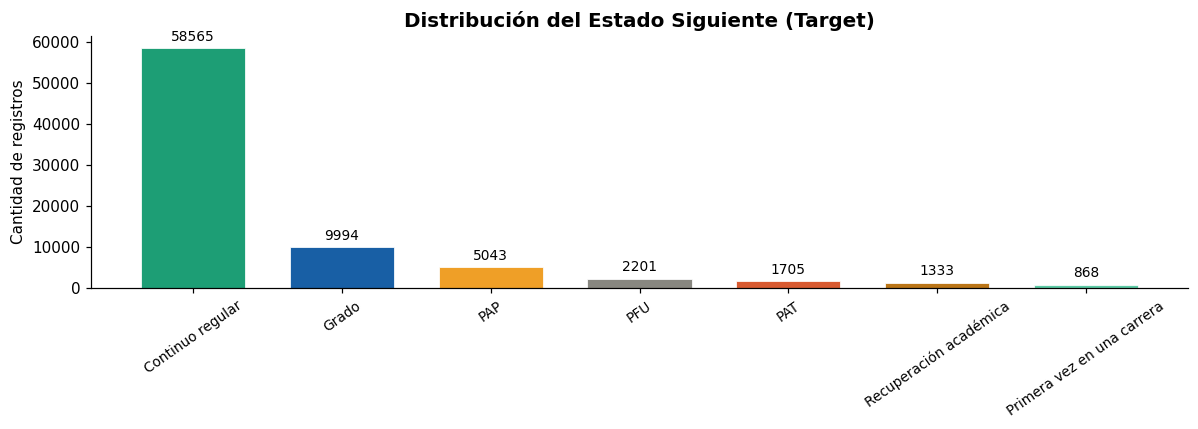

In [7]:
# Visualización: distribución del target
PALETTE = {
    'Continuo regular': '#1D9E75', 'PAP': '#EF9F27', 'PAT': '#D85A30',
    'Recuperación académica': '#BA7517', 'Grado': '#185FA5', 'PFU': '#888780',
    'Reingreso': '#534AB7', 'Reinicio': '#D4537E',
    'Primera vez en una carrera': '#5DCAA5', 'Transferencia interna': '#997756',
    'Exclusión': '#E24B4A',
}

target_counts = df_train['ESTADO_SIGUIENTE'].value_counts()
colors_dist = [PALETTE.get(c, '#888780') for c in target_counts.index]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(target_counts.index, target_counts.values, color=colors_dist,
              width=0.7, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Cantidad de registros')
ax.set_title('Distribución del Estado Siguiente (Target)', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.tick_params(axis='x', rotation=35, labelsize=9)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_distribucion_target.png', dpi=130, bbox_inches='tight')
plt.show()


In [8]:
# Ingeniería de features
df_train['ANIO'] = df_train['PERIODO'].astype(str).str[:4].astype(int)
df_train['SEMESTRE'] = df_train['PERIODO'].astype(str).str[4:].astype(int)
df_train['ANIO_INGRESO'] = df_train['PERIODO_INGRESO'].astype(str).str[:4].astype(float)
df_train['SEM_INGRESO'] = df_train['PERIODO_INGRESO'].astype(str).str[4:].astype(float)
df_train['PERIODOS_TRANSCURRIDOS'] = (
    (df_train['ANIO'] - df_train['ANIO_INGRESO']) * 2
    + (df_train['SEMESTRE'] - df_train['SEM_INGRESO'])
)

ESTADO_RIESGO = {
    'Aspirante inscrito': 0, 'Primera vez en una carrera': 1,
    'Continuo regular': 2, 'PAP': 3, 'PAT': 4,
    'Recuperación académica': 5, 'Exclusión': 6,
    'PFU': 7, 'Reingreso': 2, 'Reinicio': 1,
    'Transferencia interna': 1, 'Grado': -1, 'Final': 7,
}
df_train['NIVEL_RIESGO_ESTADO'] = df_train['AUTOMATA_ESTADO'].map(ESTADO_RIESGO).fillna(0)
df_train['RIESGO_EXCLUSION'] = df_train['RIESGO_EXCLUSION'].fillna(False).astype(int)
df_train['TUVO_RIESGO_EXCLUSION'] = df_train['TUVO_RIESGO_EXCLUSION'].fillna(False).astype(int)

le_estado = LabelEncoder()
le_programa = LabelEncoder()
le_target = LabelEncoder()

df_train['ESTADO_ACTUAL_ENC'] = le_estado.fit_transform(df_train['AUTOMATA_ESTADO'].astype(str))
df_train['PROGRAMA_ENC'] = le_programa.fit_transform(df_train['PROGRAMA'].fillna('DESCONOCIDO').astype(str))
df_train['TARGET'] = le_target.fit_transform(df_train['ESTADO_SIGUIENTE'].astype(str))

TARGET_NAMES = le_target.classes_.tolist()
print("Features de entrenamiento creados ✓")
print(f"Clases del target: {TARGET_NAMES}")


Features de entrenamiento creados ✓
Clases del target: ['Continuo regular', 'Grado', 'PAP', 'PAT', 'PFU', 'Primera vez en una carrera', 'Recuperación académica']


In [9]:
# Exportar dataset de entrenamiento
export_cols = [
    'ID', 'PERIODO', 'PROGRAMA', 'AUTOMATA_ESTADO', 'TRANSICION_AUTOMATA',
    'PROMEDIO', 'PROMEDIO_ACUMULADO', 'NRO_CURSOS_APROBADOS', 'CREDITOS_APROVADOS',
    'PERIODOS_TRANSCURRIDOS', 'RIESGO_EXCLUSION', 'TUVO_RIESGO_EXCLUSION', 'ESTADO_SIGUIENTE'
]
export_cols = [c for c in export_cols if c in df_train.columns]
df_train[export_cols].to_csv(f'{OUTPUT_DIR}/training_dataset.csv', index=False, encoding='utf-8-sig')
print(f"Dataset exportado: {OUTPUT_DIR}/training_dataset.csv")
print(df_train[export_cols].head(5).to_string(index=False))


Dataset exportado: ./outputs/training_dataset.csv
       ID  PERIODO         PROGRAMA            AUTOMATA_ESTADO TRANSICION_AUTOMATA  PROMEDIO  PROMEDIO_ACUMULADO  NRO_CURSOS_APROBADOS  CREDITOS_APROVADOS  PERIODOS_TRANSCURRIDOS  RIESGO_EXCLUSION  TUVO_RIESGO_EXCLUSION ESTADO_SIGUIENTE
T00001550   202210 INGENIERIA CIVIL Primera vez en una carrera                   a      3.64                3.64                   2.0                 NaN                     0.0                 0                      0 Continuo regular
T00001550   202220 INGENIERIA CIVIL           Continuo regular                   a      4.01                3.82                   4.0                 5.0                    10.0                 0                      0 Continuo regular
T00001550   202310 INGENIERIA CIVIL           Continuo regular                   a      4.14                3.93                   5.0                11.0                     2.0                 0                      0 Continuo regular
T0

## Fase 4 — Modelo predictivo y evaluación

In [10]:
# División train / test
FEATURE_COLS = [c for c in [
    'ESTADO_ACTUAL_ENC', 'NIVEL_RIESGO_ESTADO', 'PROMEDIO', 'PROMEDIO_ACUMULADO',
    'NRO_CURSOS_APROBADOS', 'CREDITOS_APROVADOS', 'PERIODOS_TRANSCURRIDOS',
    'PROGRAMA_ENC', 'RIESGO_EXCLUSION', 'TUVO_RIESGO_EXCLUSION',
    'PORCENTAJE_CREDITOS_GRADO', 'PORCENTAJE_MATERIAS_GRADO',
] if c in df_train.columns]

X = df_train[FEATURE_COLS].copy()
y = df_train['TARGET'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Features usados: {FEATURE_COLS}")


Train: 63,767  |  Test: 15,942
Features usados: ['ESTADO_ACTUAL_ENC', 'NIVEL_RIESGO_ESTADO', 'PROMEDIO', 'PROMEDIO_ACUMULADO', 'NRO_CURSOS_APROBADOS', 'CREDITOS_APROVADOS', 'PERIODOS_TRANSCURRIDOS', 'PROGRAMA_ENC', 'RIESGO_EXCLUSION', 'TUVO_RIESGO_EXCLUSION', 'PORCENTAJE_CREDITOS_GRADO', 'PORCENTAJE_MATERIAS_GRADO']


In [11]:
# Definir y entrenar los modelos
models = {
    'Random Forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(
            n_estimators=200, min_samples_leaf=2,
            class_weight='balanced', random_state=42, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(
            n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42
        ))
    ]),
    'Logistic Regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ))
    ]),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='mlogloss', random_state=42, n_jobs=-1
        ))
    ])

results = {}
for name, pipe in models.items():
    print(f"Entrenando {name}...", end=' ')
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = {
        'pipe': pipe, 'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'precision_weighted': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    }
    r = results[name]
    print(f"Accuracy={r['accuracy']:.4f}  F1={r['f1_weighted']:.4f}")

best_name = max(results, key=lambda n: results[n]['f1_weighted'])
best = results[best_name]
print(f"\n✓ Mejor modelo: {best_name}")


Entrenando Random Forest... Accuracy=0.9327  F1=0.9315
Entrenando Gradient Boosting... Accuracy=0.9343  F1=0.9331
Entrenando Logistic Regression... Accuracy=0.6564  F1=0.6911
Entrenando XGBoost... Accuracy=0.9334  F1=0.9317

✓ Mejor modelo: Gradient Boosting


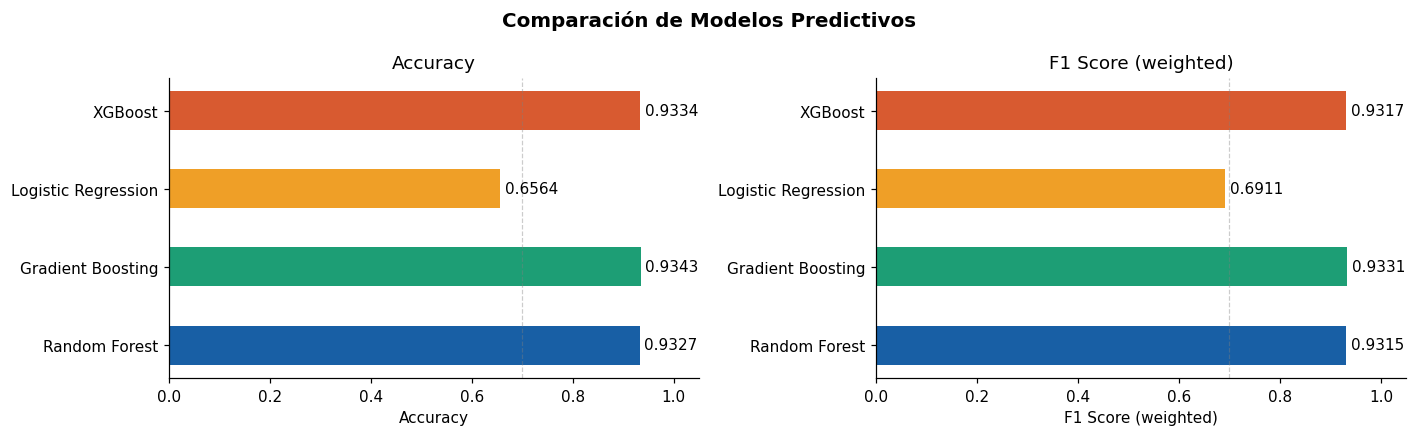

In [12]:
# Comparación de modelos (figura)
model_names = list(results.keys())
colors_models = ['#185FA5','#1D9E75','#EF9F27','#D85A30'][:len(model_names)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Comparación de Modelos Predictivos', fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes,
    ['accuracy', 'f1_weighted'], ['Accuracy', 'F1 Score (weighted)']):
    vals = [results[n][metric] for n in model_names]
    bars = ax.barh(model_names, vals, color=colors_models, height=0.5)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
    ax.axvline(x=0.7, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
    for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_comparacion_modelos.png', dpi=130, bbox_inches='tight')
plt.show()


In [13]:
# Evaluación detallada del mejor modelo
y_pred_best = best['y_pred']
print(f"=== {best_name} — Reporte de Clasificación ===\n")
print(classification_report(y_test, y_pred_best, target_names=TARGET_NAMES, zero_division=0))


=== Gradient Boosting — Reporte de Clasificación ===

                            precision    recall  f1-score   support

          Continuo regular       0.97      0.97      0.97     11713
                     Grado       0.84      0.77      0.80      1999
                       PAP       0.88      0.91      0.89      1009
                       PAT       0.87      0.95      0.91       341
                       PFU       0.91      0.95      0.93       440
Primera vez en una carrera       0.52      0.38      0.44       173
    Recuperación académica       0.72      0.85      0.78       267

                  accuracy                           0.93     15942
                 macro avg       0.82      0.83      0.82     15942
              weighted avg       0.93      0.93      0.93     15942



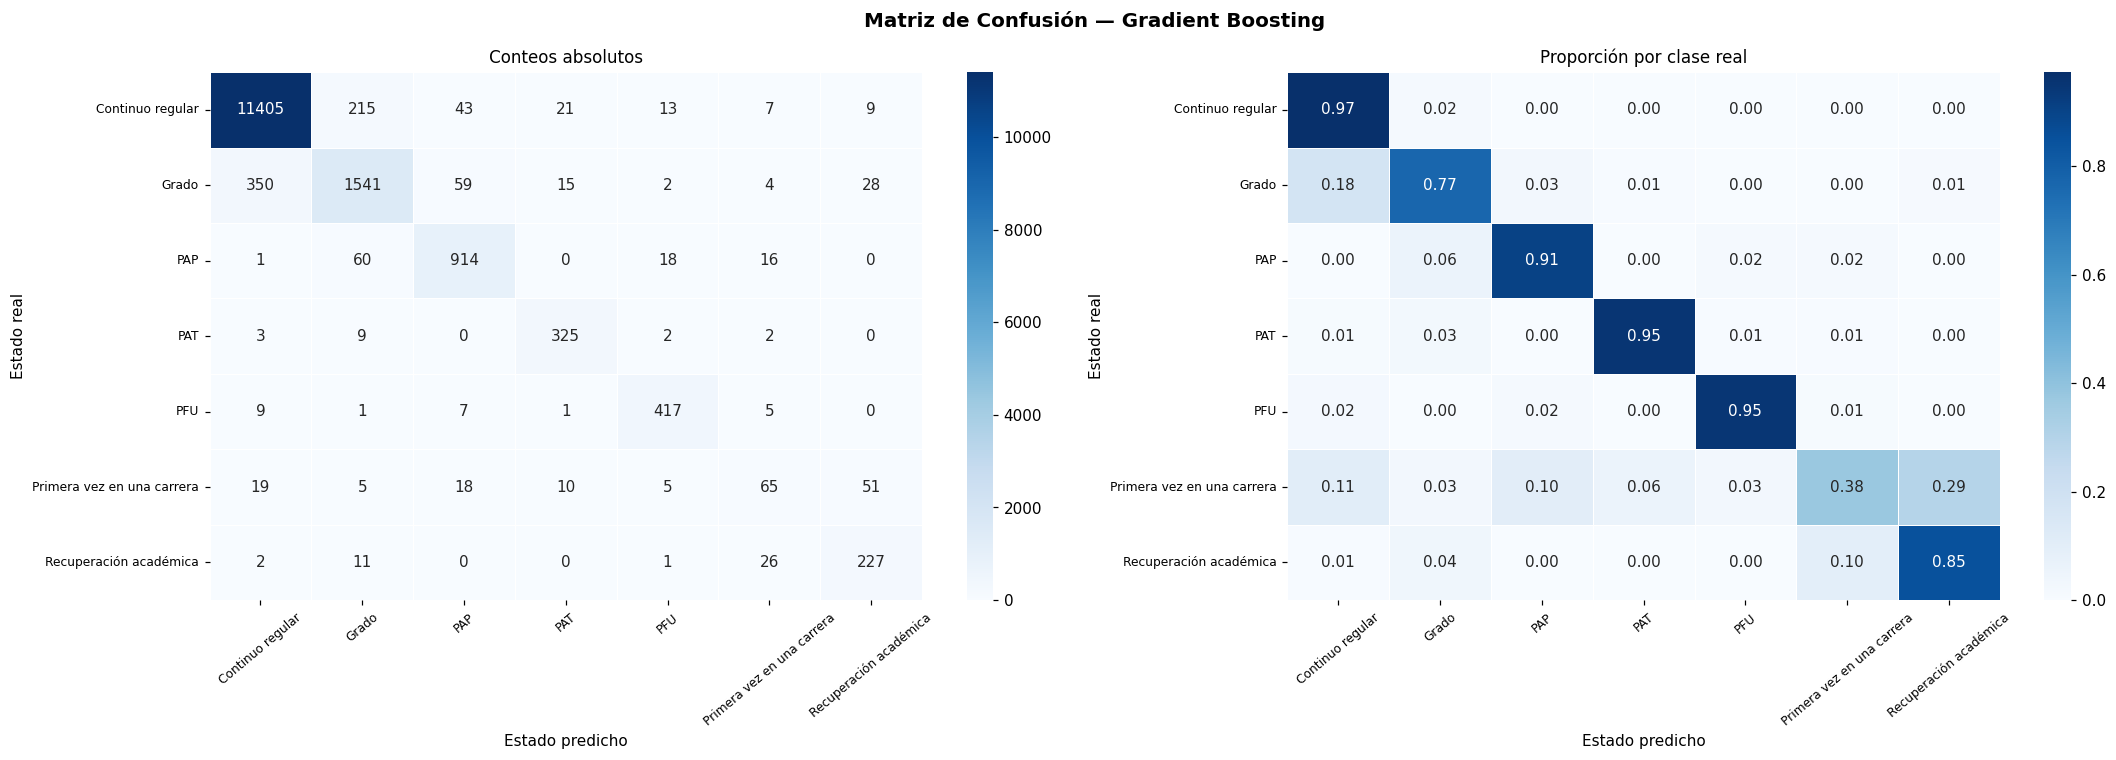

In [14]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle(f'Matriz de Confusión — {best_name}', fontsize=13, fontweight='bold')

for ax, data, title, fmt in zip(axes,
    [cm, cm_norm],
    ['Conteos absolutos', 'Proporción por clase real'],
    ['d', '.2f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
        ax=ax, linewidths=0.4, linecolor='white')
    ax.set_xlabel('Estado predicho', fontsize=10)
    ax.set_ylabel('Estado real', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()


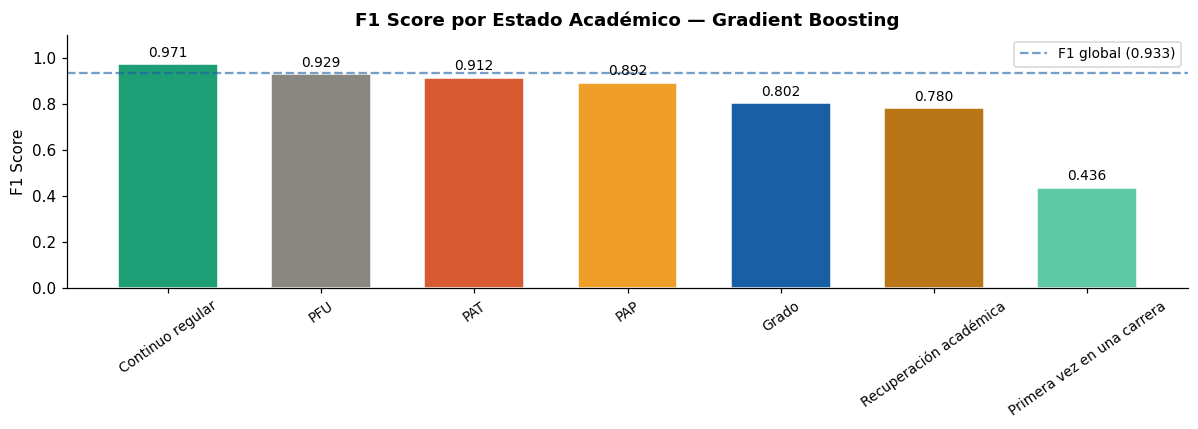

In [15]:
# F1 por clase
report_dict = classification_report(
    y_test, y_pred_best, target_names=TARGET_NAMES, zero_division=0, output_dict=True
)
f1_per_class = {cls: report_dict[cls]['f1-score'] for cls in TARGET_NAMES if cls in report_dict}
sorted_cls = sorted(f1_per_class, key=f1_per_class.get, reverse=True)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(sorted_cls, [f1_per_class[c] for c in sorted_cls],
              color=[PALETTE.get(c, '#888780') for c in sorted_cls],
              width=0.65, edgecolor='white')
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title(f'F1 Score por Estado Académico — {best_name}', fontsize=12, fontweight='bold')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.axhline(y=best['f1_weighted'], color='#185FA5', linestyle='--', alpha=0.6,
           label=f'F1 global ({best["f1_weighted"]:.3f})')
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.legend(fontsize=9)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_f1_por_clase.png', dpi=130, bbox_inches='tight')
plt.show()


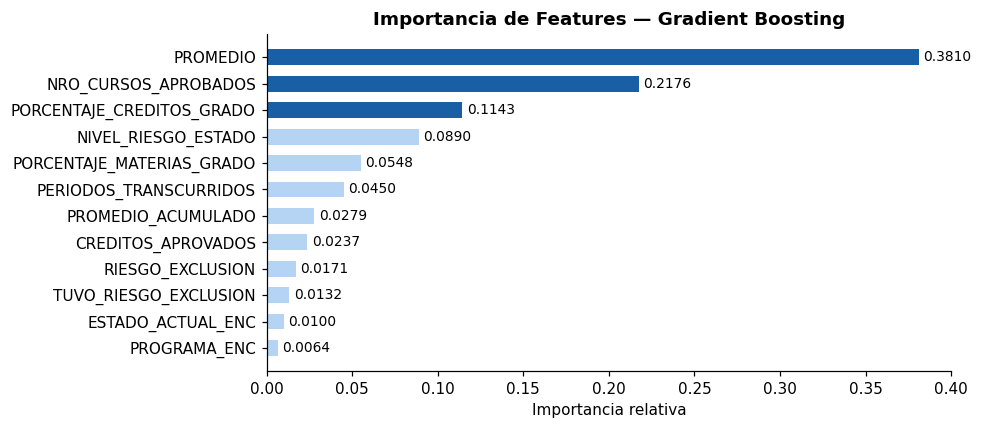

In [16]:
# Importancia de features
best_pipe = best['pipe']
clf_step = best_pipe.named_steps.get('clf', best_pipe[-1])
if hasattr(clf_step, 'feature_importances_'):
    feat_imp = pd.Series(clf_step.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 4))
    colors_imp = ['#185FA5' if v >= feat_imp.quantile(0.75) else '#B5D4F4' for v in feat_imp]
    bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_imp, height=0.6)
    ax.set_xlabel('Importancia relativa')
    ax.set_title(f'Importancia de Features — {best_name}', fontsize=12, fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    for spine in ['top','right']: ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/04_feature_importance.png', dpi=130, bbox_inches='tight')
    plt.show()


## Análisis de Trayectorias Académicas

In [17]:
# Calcular y visualizar trayectorias más frecuentes
all_acad = pd.concat([
    df_main[df_main['REGLA_AUTOMATA'] == 'ACADEMIC_TRANSITION'],
    df_grad[[c for c in df_main.columns if c in df_grad.columns]]
        [df_grad['REGLA_AUTOMATA'] == 'ACADEMIC_TRANSITION']
]).sort_values(['ID', 'ORDEN_AUTOMATA'])

trayectorias = (
    all_acad.groupby('ID')['AUTOMATA_ESTADO']
    .apply(lambda x: ' → '.join(x.tolist()))
    .reset_index()
    .rename(columns={'AUTOMATA_ESTADO': 'TRAYECTORIA'})
)

top15 = trayectorias['TRAYECTORIA'].value_counts().head(15)
print("Top 15 trayectorias más frecuentes:")
for i, (tray, cnt) in enumerate(top15.items(), 1):
    print(f"  {i:>2}. ({cnt:,} estudiantes) {tray[:90]}")


Top 15 trayectorias más frecuentes:
   1. (2,274 estudiantes) Primera vez en una carrera
   2. (1,108 estudiantes) Primera vez en una carrera → Continuo regular → Continuo regular → Continuo regular → Cont
   3. (1,086 estudiantes) Primera vez en una carrera → Continuo regular → Continuo regular → Continuo regular → Cont
   4. (664 estudiantes) Primera vez en una carrera → Continuo regular
   5. (633 estudiantes) Primera vez en una carrera → Continuo regular → Continuo regular
   6. (523 estudiantes) Primera vez en una carrera → Continuo regular → Continuo regular → Continuo regular → Cont
   7. (472 estudiantes) Primera vez en una carrera → Continuo regular → Continuo regular → Continuo regular → Cont
   8. (421 estudiantes) Primera vez en una carrera → Continuo regular → Continuo regular → Continuo regular → Cont
   9. (418 estudiantes) Primera vez en una carrera → Continuo regular → Continuo regular → Continuo regular → Cont
  10. (220 estudiantes) Primera vez en una carrera → Conti

In [18]:
# Trayectorias completas por estudiante
trayectorias_full = all_acad.groupby('ID').agg(
    PROGRAMA=('PROGRAMA', 'first'),
    N_PERIODOS=('PERIODO', 'count'),
    SECUENCIA_ESTADOS=('AUTOMATA_ESTADO', lambda x: ' → '.join(x.tolist())),
    SECUENCIA_TRANSICIONES=('TRANSICION_AUTOMATA', lambda x: ''.join(x.fillna('?').tolist())),
    ESTADO_FINAL=('AUTOMATA_ESTADO', 'last'),
).reset_index()

trayectorias_full.to_csv(f'{OUTPUT_DIR}/trayectorias_por_estudiante.csv',
                          index=False, encoding='utf-8-sig')

print("Distribución de estado final:")
print(trayectorias_full['ESTADO_FINAL'].value_counts().to_string())


Distribución de estado final:
ESTADO_FINAL
Continuo regular              8264
Primera vez en una carrera    2409
PAP                            924
PAT                            345
Recuperación académica         190
PFU                             22


## Resumen de Resultados y Respuestas a las Preguntas de Investigación

In [19]:
print("=" * 65)
print("RESUMEN DE RESULTADOS")
print("=" * 65)

print("\n── Métricas de todos los modelos ──")
for name in results:
    r = results[name]
    marker = " ← MEJOR" if name == best_name else ""
    print(f"  {name:<25}  Acc={r['accuracy']:.4f}  F1={r['f1_weighted']:.4f}{marker}")

print(f"\n── Respuestas a las preguntas de investigación ──")

top_tray = trayectorias['TRAYECTORIA'].value_counts()
print(f"\n1. Trayectoria más frecuente ({top_tray.iloc[0]} estudiantes):")
print(f"   {top_tray.index[0]}")

grad_pct = (trayectorias_full['ESTADO_FINAL'] == 'Grado').mean() * 100
print(f"\n2. Estudiantes que terminan en Grado: {grad_pct:.1f}%")

riesgo_pct = trayectorias_full['ESTADO_FINAL'].isin(['PAP','PAT','PFU','Final']).mean() * 100
print(f"   Estudiantes en riesgo / PFU: {riesgo_pct:.1f}%")

if hasattr(clf_step, 'feature_importances_'):
    top3 = pd.Series(clf_step.feature_importances_, index=FEATURE_COLS).nlargest(3)
    print(f"\n3. Variables más importantes para la predicción:")
    for feat, imp in top3.items():
        print(f"   {feat:<40} {imp:.4f}")

print(f"\n4. Desempeño del mejor modelo ({best_name}):")
print(f"   Accuracy  : {best['accuracy']:.4f}")
print(f"   F1 (w)    : {best['f1_weighted']:.4f}")
print(f"   Precision : {best['precision_weighted']:.4f}")
print(f"   Recall    : {best['recall_weighted']:.4f}")
print("=" * 65)


RESUMEN DE RESULTADOS

── Métricas de todos los modelos ──
  Random Forest              Acc=0.9327  F1=0.9315
  Gradient Boosting          Acc=0.9343  F1=0.9331 ← MEJOR
  Logistic Regression        Acc=0.6564  F1=0.6911
  XGBoost                    Acc=0.9334  F1=0.9317

── Respuestas a las preguntas de investigación ──

1. Trayectoria más frecuente (2274 estudiantes):
   Primera vez en una carrera

2. Estudiantes que terminan en Grado: 0.0%
   Estudiantes en riesgo / PFU: 10.6%

3. Variables más importantes para la predicción:
   PROMEDIO                                 0.3810
   NRO_CURSOS_APROBADOS                     0.2176
   PORCENTAJE_CREDITOS_GRADO                0.1143

4. Desempeño del mejor modelo (Gradient Boosting):
   Accuracy  : 0.9343
   F1 (w)    : 0.9331
   Precision : 0.9328
   Recall    : 0.9343
